In [38]:
import os
import pyBigWig
import numpy as np
import matplotlib.pyplot as plt

def get_signal_array(bw_path, chrom, start, end):
    with pyBigWig.open(bw_path) as bw:
        values = bw.values(chrom, start, end, numpy=True)
    return np.array([v if v is not None else np.nan for v in values])

def bin_signal(signal, bin_size):
    n = len(signal)
    trim_length = n - (n % bin_size)
    signal_trimmed = signal[:trim_length]
    binned = np.nanmean(signal_trimmed.reshape(-1, bin_size), axis=1)
    return binned

def plot_chipseq(
    chrom, start, end,
    samples=None,
    replicates=None,
    labels=None,
    colors=None,
    error_type="sem",
    figsize=(10, 4),
    output_dir=None,
    output_filename="chipseq_plot.pdf",
    bin_size=100,
    ymin=None,
    ymax=None,
    enforce_xlim=True,  
    width=10,
    height=4
):
    region_length = end - start
    n_bins = region_length // bin_size
    bin_edges = np.arange(start, start + n_bins * bin_size + 1, bin_size)
    x = (bin_edges[:-1] + bin_edges[1:]) / 2

    plot_data = []  # <--- Make sure this is here!

    if replicates is not None:
        if labels is None:
            labels = [f"Group{i+1}" for i in range(len(replicates))]
        for i, group in enumerate(replicates):
            matrix = []
            for bw in group:
                sig = get_signal_array(bw, chrom, start, end)
                binned = bin_signal(sig, bin_size)
                matrix.append(binned)
            matrix = np.array(matrix)
            mean = np.nanmean(matrix, axis=0)
            if error_type == "sd":
                error = np.nanstd(matrix, axis=0)
            elif error_type == "sem":
                error = np.nanstd(matrix, axis=0) / np.sqrt(matrix.shape[0])
            else:
                raise ValueError("error_type must be 'sd' or 'sem'")
            plot_data.append((x, mean, error, labels[i]))
    elif samples is not None:
        if labels is None:
            labels = [f"Sample{i+1}" for i in range(len(samples))]
        for i, bw in enumerate(samples):
            sig = get_signal_array(bw, chrom, start, end)
            binned = bin_signal(sig, bin_size)
            plot_data.append((x, binned, np.zeros_like(binned), labels[i]))
    else:
        raise ValueError("Either 'samples' or 'replicates' must be provided")

    plt.figure(figsize=(width, height))
    for i, (x_vals, y, err, label) in enumerate(plot_data):
        color = colors[i] if colors is not None else None
        plt.plot(x_vals, y, label=label, color=color)
        plt.fill_between(x_vals, y - err, y + err, alpha=0.3, color=color)

    plt.xlabel(f"Genomic position: {chrom}:{start}-{end}")
    plt.ylabel("Signal")
    plt.title("ChIP-seq signal")
    plt.legend()
    plt.tight_layout()

    # Force exact genomic boundaries
    if enforce_xlim:
        plt.xlim(start, end)

    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)


    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, output_filename)
        plt.savefig(output_path, format='pdf')
        print(f"Plot saved to: {output_path}")
    else:
        plt.show()

def plot_chipseq_pairwise(
    chrom, start, end,
    condA_files,
    condB_files,
    operation="difference",     # "difference" or "ratio"
    bin_size=100,
    width=10,
    height=4,
    ymin=None,
    ymax=None,
    enforce_xlim=True,  
    output_dir=None,
    output_filename="chipseq_pairwise.pdf"
):
    """
    Plot paired difference or ratio between two matched sample groups.
    Computes mean ± SEM across replicate pairs.
    """

    if len(condA_files) != len(condB_files):
        raise ValueError("condA_files and condB_files must have same length (matched replicates)")

    region_length = end - start
    n_bins = region_length // bin_size
    bin_edges = np.arange(start, start + n_bins * bin_size + 1, bin_size)
    x = (bin_edges[:-1] + bin_edges[1:]) / 2

    pairwise_matrix = []

    for bwA, bwB in zip(condA_files, condB_files):

        sigA = get_signal_array(bwA, chrom, start, end)
        sigB = get_signal_array(bwB, chrom, start, end)

        bA = bin_signal(sigA, bin_size)
        bB = bin_signal(sigB, bin_size)

        if operation == "difference":
            result = bA - bB

        elif operation == "ratio":
            # Avoid division by zero
            with np.errstate(divide='ignore', invalid='ignore'):
                result = np.where(bB != 0, bA / bB, np.nan)

        else:
            raise ValueError("operation must be 'difference' or 'ratio'")

        pairwise_matrix.append(result)

    pairwise_matrix = np.array(pairwise_matrix)

    mean = np.nanmean(pairwise_matrix, axis=0)
    sem = np.nanstd(pairwise_matrix, axis=0) / np.sqrt(pairwise_matrix.shape[0])

    # Plot
    plt.figure(figsize=(width, height))
    plt.plot(x, mean, label=f"Mean {operation}", color="black")
    plt.fill_between(x, mean - sem, mean + sem, alpha=0.3)

    plt.axhline(0 if operation == "difference" else 1,
                linestyle="--", color="gray", linewidth=1)

    plt.xlabel(f"{chrom}:{start}-{end}")
    plt.ylabel(operation)
    plt.title(f"Paired {operation} (mean ± SEM)")
    plt.legend()
    plt.tight_layout()
    # Force exact genomic boundaries
    if enforce_xlim:
        plt.xlim(start, end)

    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)


    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, output_filename)
        plt.savefig(output_path, format='pdf')
        print(f"Plot saved to: {output_path}")
    else:
        plt.show()

def export_pairwise_bigwig(
    bwA_path,
    bwB_path,
    output_bw,
    operation="ratio",      # "ratio" or "difference"
    bin_size=100,
    pseudocount=1e-6
):
    """
    Create a new bigWig representing the ratio or difference between two bigWigs.

    Parameters
    ----------
    bwA_path : str
        Path to first bigWig
    bwB_path : str
        Path to second bigWig
    output_bw : str
        Path to output bigWig
    operation : str
        "ratio" or "difference"
    bin_size : int
        Bin size in bp (default 100)
    pseudocount : float
        Value added to avoid division by zero
    """

    bwA = pyBigWig.open(bwA_path)
    bwB = pyBigWig.open(bwB_path)

    # Get chromosome sizes
    chroms = bwA.chroms()

    # Create output bigWig
    out = pyBigWig.open(output_bw, "w")
    header = [(chrom, size) for chrom, size in chroms.items()]
    out.addHeader(header)

    for chrom, size in chroms.items():

        print(f"Processing {chrom}")

        starts = np.arange(0, size, bin_size)
        ends = np.minimum(starts + bin_size, size)

        values = []

        for s, e in zip(starts, ends):

            sigA = bwA.values(chrom, int(s), int(e), numpy=True)
            sigB = bwB.values(chrom, int(s), int(e), numpy=True)

            meanA = np.nanmean(sigA)
            meanB = np.nanmean(sigB)

            if operation == "ratio":
                val = (meanA + pseudocount) / (meanB + pseudocount)

            elif operation == "difference":
                val = meanA - meanB

            else:
                raise ValueError("operation must be 'ratio' or 'difference'")

            values.append(val)

        out.addEntries(
            [chrom] * len(starts),
            starts.tolist(),
            ends=ends.tolist(),
            values=np.array(values, dtype=float).tolist()
        )

    bwA.close()
    bwB.close()
    out.close()

    print(f"Output bigWig written to: {output_bw}")

Example with replicates and then without replicates

In [4]:
#example 1
replicates = [
    ["data/condA_rep1.bw", "data/condA_rep2.bw"],
    ["data/condB_rep1.bw", "data/condB_rep2.bw"]
]
labels = ["Condition A", "Condition B"]
colors = ["#1f77b4", "#ff7f0e"]

plot_chipseq(
    chrom="chr1", start=100000, end=101000,
    replicates=replicates,
    labels=labels,
    colors=colors,
    error_type="sem",
    output_dir="results/plots",
    output_filename="chipseq_chr1_regionA.pdf"
)
#example 2
samples = ["data/sample1.bw", "data/sample2.bw"]
labels = ["Sample 1", "Sample 2"]

plot_chipseq(
    chrom="chr2", start=50000, end=51000,
    samples=samples,
    labels=labels,
    output_dir="results/plots",
    output_filename="chipseq_chr2_simple.pdf"
)

Code to run on independent samples

In [45]:
inputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Calibrated_tracks/"
outputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/"
samples = [str(inputdir + "JS43^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^LMNA57.CPM.calibrated.bw"),
           str(inputdir + "JS41^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^GBLVS3.CPM.calibrated")]
labels = ["FWD", "REV"]
colors = ["#1f77b4", "#ff7f0e"]
plot_chipseq(
    chrom="chr5",
    start=98000,
    end=138000,
    samples=samples,
    labels=labels,
    colors=colors,
    output_dir=outputdir,
    output_filename="chipseq_fixed_ylim.pdf",
    bin_size=100,
    ymin=0,
    ymax=300,
    width=10,
    height=6
)

/tmp/ipykernel_739/1941144741.py:15: RuntimeWarning: Mean of empty slice
  binned = np.nanmean(signal_trimmed.reshape(-1, bin_size), axis=1)
[urlOpen] Couldn't open /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Calibrated_tracks/JS41^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^GBLVS3.CPM.calibrated for reading
[urlOpen] Couldn't open /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Calibrated_tracks/JS41^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^GBLVS3.CPM.calibrated for reading
[pyBwOpen] bw is NULL!


RuntimeError: Received an error during file opening!

Plot Calibrated IPs

/tmp/ipykernel_21335/2786556717.py:15: RuntimeWarning: Mean of empty slice
  binned = np.nanmean(signal_trimmed.reshape(-1, bin_size), axis=1)


Plot saved to: /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/chipseq_V5-Rad51_WT_rad57_srs2_2h_IPcal_chr2-250000-500000_ylim25_bin4000bp_sem.pdf


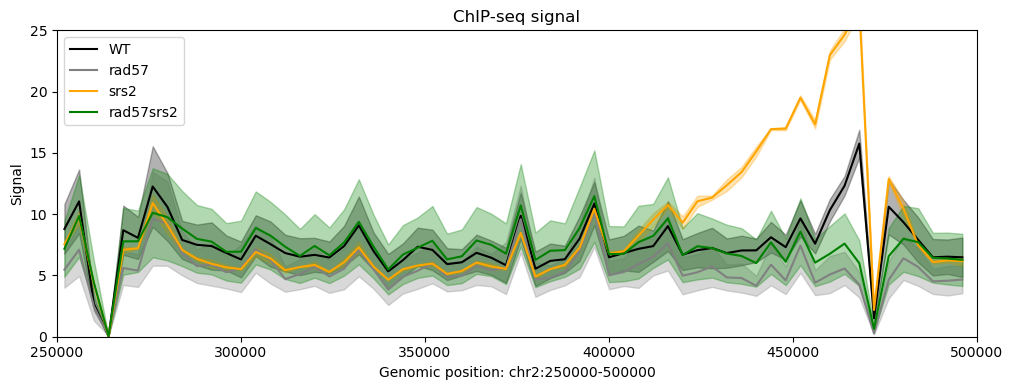

In [63]:

# Plot with replicates
inputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Calibrated_tracks/"
#inputdir="/mnt/e/Science/ChIP/Jerome/S288c_DSB_LY_Capture_N/"
outputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/"
#==============================================================================
chromosome="chr5"
chr_start=78000
chr_end=158000
chr_start=18000
chr_end=218000
ylim=300
binning=1000
#==============================================================================
chromosome="chr2"
#chr_start=370000
#chr_end=570000
chr_start=0
chr_end=813000
chr_start=250000
chr_end=500000
ylim=25
binning=4000
#==============================================================================
#DSB 2h
replicates = [
    [str(inputdir + "JS43^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^LMNA57.CPM.calibrated.bw"),
    str(inputdir + "JS105^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^MZV2JL.CPM.calibrated.bw"),
    str(inputdir + "CD29^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^ZZROHQ.CPM.calibrated.bw")],
    [str(inputdir + "CD30^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^M1GNJY.CPM.calibrated.bw"),
    str(inputdir + "JS97^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^HFXF4F.CPM.calibrated.bw")],
    [str(inputdir + "JS98^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^D7YC7N.CPM.calibrated.bw"),
    str(inputdir + "CD31^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^DKWB7I.CPM.calibrated.bw")],
    [str(inputdir + "JS106^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^HYO4CO.CPM.calibrated.bw"),
    str(inputdir + "CD32^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^8QA6G5.CPM.calibrated.bw")]
]
#DSB 4h
#replicates = [
#    [str(inputdir + "JS49^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^E0OJSO.CPM.calibrated.bw"),
#    str(inputdir + "JS107^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^KX255X.CPM.calibrated.bw"),
#    str(inputdir + "CD37^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^2D57XF.CPM.calibrated.bw")],
#    [str(inputdir + "CD38^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^P6BHVD.CPM.calibrated.bw"),
#    str(inputdir + "JS99^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^PIB1XD.CPM.calibrated.bw")],
#    [str(inputdir + "JS100^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^U94I9L.CPM.calibrated.bw"),
#    str(inputdir + "CD39^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^K9WB02.CPM.calibrated.bw")],
#    [str(inputdir + "JS108^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^LWTMHA.CPM.calibrated.bw"),
#    str(inputdir + "CD40^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^PH30JA.CPM.calibrated.bw")]
#]

labels = ["WT", "rad57", "srs2", "rad57srs2"]
colors = ["black", "grey", "orange", "green"]
output_name=str("chipseq_V5-Rad51_WT_rad57_srs2_2h_IPcal_" + str(chromosome) + "-" + str(chr_start) + "-" + str(chr_end) +
                "_ylim" + str(ylim) + "_bin" + str(binning) + "bp_sem.pdf")


plot_chipseq(
    chrom=chromosome,
    start=chr_start,
    end=chr_end,
    replicates=replicates, 
    error_type='sem',
    labels=labels,
    colors=colors,
    output_dir=outputdir,
    output_filename=output_name,
    bin_size=binning,
    ymin=0,
    ymax=ylim,
    enforce_xlim=True,  
    width=10,
    height=4
)


Plot strandedness

/tmp/ipykernel_21335/1880756627.py:15: RuntimeWarning: Mean of empty slice
  binned = np.nanmean(signal_trimmed.reshape(-1, bin_size), axis=1)
/tmp/ipykernel_21335/1880756627.py:52: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(matrix, axis=0)
/home/apiazza/miniconda3/envs/jupyter_chip/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Plot saved to: /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/chipseq_V5-Rad51_WT_rad57_srs2_2h_IPcal_strandedness_chr5-18000-218000_ylim8_bin1000bp_sem.pdf


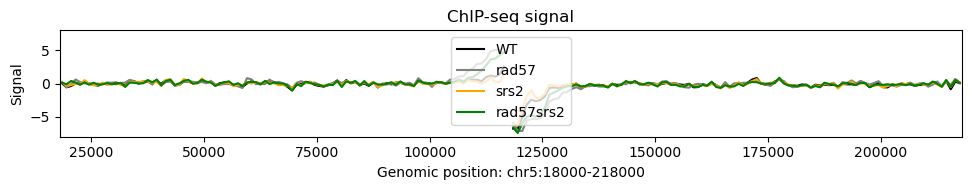

In [23]:
# Plot strandedness with replicates
inputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Strandedness_tracks/"
outputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/"
#==============================================================================
chromosome="chr5"
chr_start=78000
chr_end=158000
chr_start=18000
chr_end=218000
xmin=chr_start
xmax=chr_end
ybtm=-8
ymax=8
binning=1000
#==============================================================================
chromosome="chr2"
chr_start=0
chr_end=813000
#chr_start=370000
#chr_end=570000
ybtm=-2
ymax=1
binning=5000
#==============================================================================
#DSB 2h
replicates = [
    [str(inputdir + "JS43^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^ZRU9PA.FWD-vs-REV.bw"),
    str(inputdir + "JS105^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^GQ03HK.FWD-vs-REV.5bp-binning.bw"),
    str(inputdir + "CD29^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^ZZROHQ.FWD-vs-REV.5bp-binning.bw")],
    [str(inputdir + "CD30^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^M1GNJY.FWD-vs-REV.5bp-binning.bw"),
    str(inputdir + "JS97^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^DGGK3O.FWD-vs-REV.5bp-binning.bw")],
    [str(inputdir + "JS98^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^D7YC7N.FWD-vs-REV.5bp-binning.bw"),
    str(inputdir + "CD31^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^DKWB7I.FWD-vs-REV.5bp-binning.bw")],
    [str(inputdir + "JS106^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^HYO4CO.FWD-vs-REV.5bp-binning.bw"),
    str(inputdir + "CD32^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^8QA6G5.FWD-vs-REV.5bp-binning.bw")]
]
#DSB 4h
#replicates = [
#    [str(inputdir + "JS49^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^ST2KCY.FWD-vs-REV.bw"),
#    str(inputdir + "JS107^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^3QSHBI.FWD-vs-REV.5bp-binning.bw"),
#    str(inputdir + "CD37^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^2D57XF.FWD-vs-REV.5bp-binning.bw")],
#    [str(inputdir + "CD38^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^P6BHVD.FWD-vs-REV.5bp-binning.bw"),
#    str(inputdir + "JS99^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^DZW11N.FWD-vs-REV.5bp-binning.bw")],
#    [str(inputdir + "JS100^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^U94I9L.FWD-vs-REV.5bp-binning.bw"),
#    str(inputdir + "CD39^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^K9WB02.FWD-vs-REV.5bp-binning.bw")],
#    [str(inputdir + "JS108^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^LWTMHA.FWD-vs-REV.5bp-binning.bw"),
#    str(inputdir + "CD40^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^PH30JA.FWD-vs-REV.5bp-binning.bw")]
#]

labels = ["WT", "rad57", "srs2", "rad57srs2"]
colors = ["black", "grey", "orange", "green"]
output_name=str("chipseq_V5-Rad51_WT_rad57_srs2_2h_IPcal_strandedness_" + str(chromosome) + "-" + str(chr_start) + "-" + str(chr_end) + "_ylim" 
                + str(ymax) + "_bin" + str(binning) + "bp_sem.pdf")


plot_chipseq(
    chrom=chromosome,
    start=chr_start,
    end=chr_end,
    replicates=replicates, 
    error_type='sem',
    labels=labels,
    colors=colors,
    output_dir=outputdir,
    output_filename=output_name,
    bin_size=binning,
    ymin=ybtm,
    ymax=ymax,
    enforce_xlim=True,  
    width=10,
    height=2
)


Compute ratio of 2 chip datasets. Match replicates

/tmp/ipykernel_21335/1880756627.py:15: RuntimeWarning: Mean of empty slice
  binned = np.nanmean(signal_trimmed.reshape(-1, bin_size), axis=1)
/tmp/ipykernel_21335/1880756627.py:150: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(pairwise_matrix, axis=0)
/home/apiazza/miniconda3/envs/jupyter_chip/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Plot saved to: /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/chipseq_compare_ratio_V5-Rad51_srs2_over_rad57_4h_IPcal_chr2-270000-570000_ylim14_bin1000bp_sem.pdf


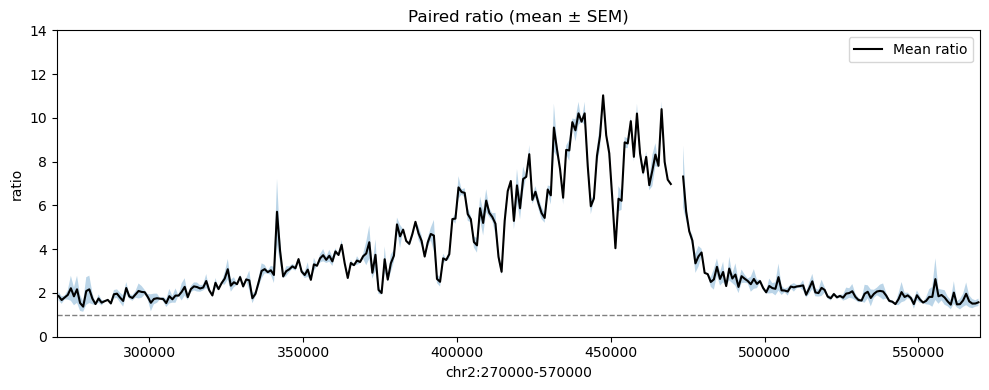

In [37]:
# Plot with replicates
inputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Calibrated_tracks/"
#inputdir="/mnt/e/Science/ChIP/Jerome/S288c_DSB_LY_Capture_N/"
outputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/"
mode="ratio" #can be difference or ratio
chromosome="chr2"
chr_start=270000
chr_end=570000
#chr_start=0
#chr_end=813000
#chr_start=300000
#chr_start=200000
#chr_end=500000
#chromosome="chr5"
#chr_start=18000
#chr_end=218000
ybtm=0
ymax=14
binning=1000

#replicates = [
#    [str(inputdir + "JS43^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^LMNA57.CPM.calibrated.bw"),
#    str(inputdir + "JS105^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^MZV2JL.CPM.calibrated.bw")],
#    [str(inputdir + "JS41^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^GBLVS3.CPM.calibrated.bw")],
#    [str(inputdir + "JS54^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^696BBH.CPM.calibrated.bw")],
#    [#str(inputdir + "JS42^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^B3P7AU.CPM.calibrated.bw"),
#    str(inputdir + "CD17^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^9DVLJ5.CPM.calibrated.bw")]
#]

#replicates = [
#    [str(inputdir + "JS49^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^E0OJSO.CPM.calibrated.bw"),
#    str(inputdir + "JS107^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^KX255X.CPM.calibrated.bw")],
#    [str(inputdir + "JS47^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^16M7WZ.CPM.calibrated.bw")],
#    [str(inputdir + "JS56^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^JMGUYC.CPM.calibrated.bw")],
#    [#str(inputdir + "JS48^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^O5W5O1.CPM.calibrated.bw"),
#    str(inputdir + "CD18^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^NJW5NJ.CPM.calibrated.bw")]
#]

#2h
cond1=[str(inputdir + "JS19^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^SJI65S.CPM.calibrated.bw"),
      str(inputdir + "JS61^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^UWQG0I.CPM.calibrated.bw")]
cond2=[str(inputdir + "JS20^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^JPYL6P.CPM.calibrated.bw"),
      str(inputdir + "JS62^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^W8AR90.CPM.calibrated.bw")]
    
#4h
cond1=[str(inputdir + "JS100^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^U94I9L.CPM.calibrated.bw"),
       str(inputdir + "CD39^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^K9WB02.CPM.calibrated.bw")]
cond2=[str(inputdir + "JS99^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^PIB1XD.CPM.calibrated.bw"),
       str(inputdir + "CD38^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^P6BHVD.CPM.calibrated.bw")]
 

output_name=str("chipseq_compare_" + str(mode) + "_V5-Rad51_srs2_over_rad57_4h_IPcal_" + str(chromosome) + "-" + str(chr_start) + "-" + str(chr_end) +
                "_ylim" + str(ymax) + "_bin" + str(binning) + "bp_sem.pdf")

plot_chipseq_pairwise(
    chrom=chromosome,
    start=chr_start,
    end=chr_end,
    condA_files=cond1,
    condB_files=cond2,
    operation=mode,
    bin_size=binning,
    ymin=ybtm,
    ymax=ymax,
    enforce_xlim=True,  
    output_dir=outputdir,
    output_filename=output_name
)


In [66]:
inputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Calibrated_tracks/"
#inputdir="/mnt/e/Science/ChIP/Jerome/S288c_DSB_LY_Capture_N/"
outputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Ratio/"
mode="ratio" #can be difference or ratio
binning=100
numerator="CD39^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^K9WB02.CPM.calibrated.bw"
denominator="CD38^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^P6BHVD.CPM.calibrated.bw"
output_name=str(mode + "_CD39_over_CD38_bin" + str(binning) + "bp.bw")

export_pairwise_bigwig(
    bwA_path=str(inputdir + numerator),
    bwB_path=str(inputdir + denominator),
    output_bw=str(outputdir + output_name),
    operation=mode,
    bin_size=binning
)

Processing chr1


/tmp/ipykernel_21335/2786556717.py:234: RuntimeWarning: Mean of empty slice
  meanA = np.nanmean(sigA)
/tmp/ipykernel_21335/2786556717.py:235: RuntimeWarning: Mean of empty slice
  meanB = np.nanmean(sigB)


Processing chr2
Processing chr3
Processing chr4
Processing chr5
Processing chr6
Processing chr7
Processing chr8
Processing chr9
Processing chr10
Processing chr11
Processing chr12
Processing chr13
Processing chr14
Processing chr15
Processing chr16
Processing 2_micron
Processing mitochondrion
Output bigWig written to: /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Ratio/ratio_CD39_over_CD38_bin100bp.bw


Plot Input

Plot saved to: /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/chipseq_V5-Rad51_WT_rad57_srs2_2h_Input_over_median_chr5-18000-218000_ylim2_bin1000bp_sem.pdf


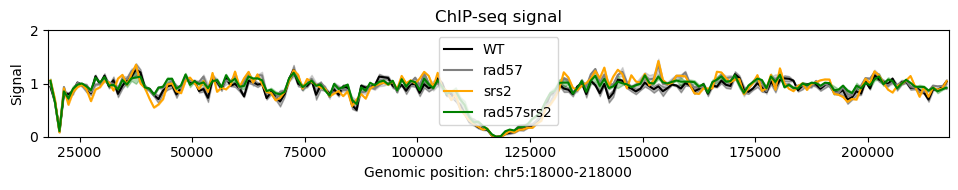

In [30]:

# Plot Inputs with replicates
inputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Input_tracks/"
#inputdir="/mnt/e/Science/ChIP/Jerome/S288c_DSB_LY_Capture_N/"
outputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/"
#==============================================================================
chromosome="chr5"
chr_start=78000
chr_end=158000
chr_start=18000
chr_end=218000
#chr_start=88000
#chr_end=148000
ylim=2
binning=1000
#==============================================================================
#chromosome="chr2"
#chr_start=370000
#chr_end=570000
#chr_start=0
#chr_end=813000
#ylim=100
#binning=5000
#==============================================================================
#DSB 2h
replicates = [
    [str(inputdir + "JS46^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^LMNA57.CPM_normalized_over_median_bin200bp.bw"),
    str(inputdir + "JS109^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^MZV2JL.CPM_normalized_over_median_bin200bp.bw"),
    str(inputdir + "CD33^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^ZZROHQ.CPM_normalized_over_median_bin200bp.bw")],
    [str(inputdir + "JS101^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^HFXF4F.CPM_normalized_over_median_bin200bp.bw"),
    str(inputdir + "CD34^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^M1GNJY.CPM_normalized_over_median_bin200bp.bw")],
    [str(inputdir + "JS102^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^D7YC7N.CPM_normalized_over_median_bin200bp.bw")
     #,
    #str(inputdir + "CD35^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^DKWB7I.CPM_normalized_over_median_bin200bp.bw")
        ],
    [str(inputdir + "JS110^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^HYO4CO.CPM_normalized_over_median_bin200bp.bw"),
    str(inputdir + "CD36^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^8QA6G5.CPM_normalized_over_median_bin200bp.bw")]
]
#DSB 4h
#replicates = [
#    [str(inputdir + "JS52^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^ST2KCY.CPM_normalized_over_median_bin200bp.bw"),
#    str(inputdir + "JS111^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^KX255X.CPM_normalized_over_median_bin200bp.bw"),
#    str(inputdir + "CD41^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^2D57XF.CPM_normalized_over_median_bin200bp.bw")],
#    [str(inputdir + "JS103^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^PIB1XD.CPM_normalized_over_median_bin200bp.bw"),
#    str(inputdir + "CD42^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^P6BHVD.CPM_normalized_over_median_bin200bp.bw")],
#    [str(inputdir + "JS104^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^PK9W2R.CPM_normalized_over_median_bin200bp.bw"),
#    str(inputdir + "CD43^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^K9WB02.CPM_normalized_over_median_bin200bp.bw")],
#    [str(inputdir + "JS112^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^LWTMHA.CPM_normalized_over_median_bin200bp.bw"),
#    str(inputdir + "CD44^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^PH30JA.CPM_normalized_over_median_bin200bp.bw")]
#]

labels = ["WT", "rad57", "srs2", "rad57srs2"]
colors = ["black", "grey", "orange", "green"]
output_name=str("chipseq_V5-Rad51_WT_rad57_srs2_2h_Input_over_median_" + str(chromosome) + "-" + str(chr_start) + "-" + str(chr_end) +
                "_ylim" + str(ylim) + "_bin" + str(binning) + "bp_sem.pdf")


plot_chipseq(
    chrom=chromosome,
    start=chr_start,
    end=chr_end,
    replicates=replicates, 
    error_type='sem',
    labels=labels,
    colors=colors,
    output_dir=outputdir,
    output_filename=output_name,
    bin_size=binning,
    ymin=0,
    ymax=ylim,
    enforce_xlim=True,  
    width=10,
    height=2
)


/tmp/ipykernel_1315/1880756627.py:15: RuntimeWarning: Mean of empty slice
  binned = np.nanmean(signal_trimmed.reshape(-1, bin_size), axis=1)
/tmp/ipykernel_1315/1880756627.py:52: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(matrix, axis=0)
/home/apiazza/miniconda3/envs/jupyter_chip/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Plot saved to: /mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/chipseq_V5-Rdh54_Rdh54-KR_2h_IPcal_strandedness_chr2-0-813000_ylim1_bin5000bp_sem.pdf


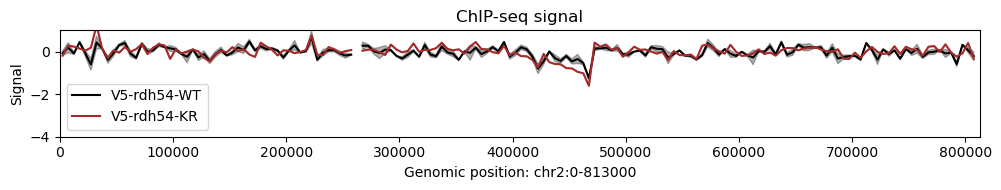

In [165]:

# Plot strandedness with replicates
inputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_tinymapper/_Strandedness_tracks/"
outputdir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/ChIP/_plot/"

chromosome="chr2"
chr_start=0
chr_end=813000
#chr_start=370000
#chr_end=570000
ybtm=-4
ymax=1
binning=5000
replicates = [
    [str(inputdir + "JS20^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^FZGPS7.FWD-vs-REV.5bp-binning.bw"),
    str(inputdir + "JS62^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^TCDYIA.FWD-vs-REV.5bp-binning.bw")],
    [str(inputdir + "JS63^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^UKYU4D.FWD-vs-REV.5bp-binning.bw")]
]

#replicates = [
#    [str(inputdir + "JS24^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^3QWS7H.FWD-vs-REV.5bp-binning.bw"),
#    str(inputdir + "JS70^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^V6YZEL.FWD-vs-REV.5bp-binning.bw")],
#    [str(inputdir + "JS71^unmapped_GCF_000002545.3_ASM254v2_genomic^mapped_S288c_DSB_LY_Capture_N^filtered^K6LGJM.FWD-vs-REV.5bp-binning.bw")]
#]


output_name=str("chipseq_V5-Rdh54_Rdh54-KR_2h_IPcal_strandedness_" + str(chromosome) + "-" + str(chr_start) + "-" + str(chr_end) + "_ylim" 
                + str(ymax) + "_bin" + str(binning) + "bp_sem.pdf")
labels = ["V5-rdh54-WT", "V5-rdh54-KR"]
colors = ["black", "brown"]

plot_chipseq(
    chrom=chromosome,
    start=chr_start,
    end=chr_end,
    replicates=replicates, 
    error_type='sem',
    labels=labels,
    colors=colors,
    output_dir=outputdir,
    output_filename=output_name,
    bin_size=binning,
    ymin=ybtm,
    ymax=ymax,
    enforce_xlim=True, 
    width=10,
    height=2
)